# Checking the difference in the number of candidates from $B^0$ 

https://raw.githubusercontent.com/bcouturi/phys/main/Category_19.png

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import uproot
from numba import jit
%matplotlib inline 

## Loading the file

In [2]:
datatype = "2012"
eventtype = "23903000"
polarity = "magdown"
sign = "rs"

In [3]:
def get_tree(datatype, eventtype, polarity, sign):
    #data_prefix = "root://eoslhcb.cern.ch//eos/lhcb/wg/semileptonic/RDsHad/AP/pidgen_merged/"
    data_prefix = "root://eoslhcb.cern.ch//eos/lhcb/user/b/bcouturi/rds/pidgen_merged/"

    filename =  data_prefix + f"rds_categ_{datatype}_{eventtype}_{polarity}_{sign}.root"
    print(f"Loading DecayTree from {filename}")
    dt = uproot.open(filename + ":DecayTree")
    return dt

In [4]:
def create_df(dt):
    # Extracting the ancestry information
    arrs = dt.arrays(["B_M", "p1_fromY_PANC_IDs", "p2_fromY_PANC_IDs", "p3_fromY_PANC_IDs"], "category == 19")
    res = {}

    @jit(nopython=True) 
    def pprint(a):
        return ":".join([ str(int(p)) for p in a if p != 0])

    @jit(nopython=True) 
    def top_decay(a):
        return ":".join([ str(abs(int(p))) for p in a if p != 0 and abs(p) >= 500])

    for i in range(1,4):
        tmp = arrs[f"p{i}_fromY_PANC_IDs"]
        res[f"p{i}_fromY_DECAY"] = [ pprint(p) for p in tmp ]
        res[f"p{i}_fromY_TOP"] = [ top_decay(p) for p in tmp ]
    res["B_M"] = arrs["B_M"]
    df = pd.DataFrame(res)
    return df

In [5]:
def mygroupby(d, groupbycols):
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

## Loading the data for event type 23903000

In [6]:
dt = get_tree(datatype, eventtype, polarity, sign)
df23903000 = create_df(dt)

Loading DecayTree from root://eoslhcb.cern.ch//eos/lhcb/user/b/bcouturi/rds/pidgen_merged/rds_categ_2012_23903000_magdown_rs.root


/cvmfs/lhcbdev.cern.ch/conda/envs/default/2023-01-19_13-58/linux-64/lib/python3.9/site-packages/awkward1/__init__.py:12: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if distutils.version.LooseVersion(numpy.__version__) < distutils.version.LooseVersion(
/cvmfs/lhcbdev.cern.ch/conda/envs/default/2023-01-19_13-58/linux-64/lib/python3.9/site-packages/awkward1/nplike.py:57: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  bool = numpy.bool
/cvmfs/lhcbdev.cern.ch/conda/envs/default/2023-01-19_13-58/linux-64/lib/python3.9/site-packages/awkward1/nplike.py:78: DeprecationWarning: `np.object` is a deprecated alias for the builtin 

In [7]:
g23903000_hb = mygroupby(df23903000[df23903000.B_M > 4800 ], 'p1_fromY_TOP')
g23903000_lb = mygroupby(df23903000[df23903000.B_M < 4800 ], 'p1_fromY_TOP')

## Loading the data for event type 23903003

In [8]:
dt23903003 = get_tree(datatype, "23903003", polarity, sign)
df23903003 = create_df(dt23903003)

Loading DecayTree from root://eoslhcb.cern.ch//eos/lhcb/user/b/bcouturi/rds/pidgen_merged/rds_categ_2012_23903003_magdown_rs.root


In [9]:
g23903003_hb = mygroupby(df23903003[df23903003.B_M > 4800 ], 'p1_fromY_TOP')
g23903003_lb = mygroupby(df23903003[df23903003.B_M < 4800 ], 'p1_fromY_TOP')

## Display repartitions

In [27]:
limit = 4800.0
df23903000['HIGH_B_M'] = df23903000.B_M > limit 
mygroupby(df23903000, 'HIGH_B_M')

,HIGH_B_M,count,Percentage,cumulative %
0,False,28619,89.988366,89.988366
1,True,3184,10.011634,100.000000


In [28]:
df23903003['HIGH_B_M'] = df23903003.B_M > limit 
mygroupby(df23903003, 'HIGH_B_M')

,HIGH_B_M,count,Percentage,cumulative %
0,False,35072,95.392482,95.392482
1,True,1694,4.607518,100.000000


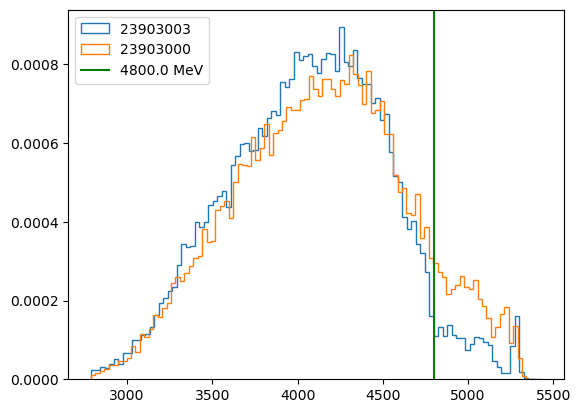

In [29]:
plt.hist(df23903003.B_M, bins=100, histtype='step', label='23903003', density=True)
plt.hist(df23903000.B_M, bins=100, histtype='step', label='23903000', density=True)
plt.axvline(x =4800, color = 'g', label = f'{limit} MeV')
plt.legend();

In [12]:
g23903000_hb[0:10]

,p1_fromY_TOP,count,Percentage,cumulative %
0,511:513,2074,65.138191,65.138191
1,511,680,21.356784,86.494975
2,511:513:20523,90,2.826633,89.321608
3,511:525,50,1.570352,90.891960
4,511:513:20513,47,1.476131,92.368090
5,511:513:525,39,1.224874,93.592965
6,511:515,30,0.942211,94.535176
7,511:513:10523,29,0.910804,95.445980
8,511:513:20533,26,0.816583,96.262563
9,511:513:515,20,0.628141,96.890704


In [13]:
g23903003_hb[0:10]

,p1_fromY_TOP,count,Percentage,cumulative %
0,511:513,1087,64.167651,64.167651
1,511,354,20.897285,85.064935
2,511:513:20523,62,3.659976,88.724911
3,511:525,31,1.829988,90.554900
4,511:513:525,23,1.357733,91.912633
5,511:513:20513,22,1.298701,93.211334
6,511:513:10523,20,1.180638,94.391972
7,511:10521,15,0.885478,95.277450
8,511:515,13,0.767414,96.044864
9,511:513:515,13,0.767414,96.812279


In [14]:
g23903000_lb[0:10]

,p1_fromY_TOP,count,Percentage,cumulative %
0,511:513,14499,50.662148,50.662148
1,511,5073,17.725986,68.388134
2,20213:511:513,2659,9.291030,77.679164
3,20213:511,923,3.225130,80.904294
4,511:513:20523,716,2.501834,83.406129
5,20313:511:513,656,2.292184,85.698312
6,511:525,441,1.540934,87.239247
7,511:513:20513,389,1.359237,88.598484
8,511:513:525,320,1.118138,89.716622
9,20313:511,236,0.824627,90.541249


In [15]:
g23903003_lb[0:10]

,p1_fromY_TOP,count,Percentage,cumulative %
0,511:513,17175,48.970689,48.970689
1,511,5969,17.019275,65.989964
2,20213:511:513,3948,11.256843,77.246807
3,20213:511,1438,4.100137,81.346943
4,20313:511:513,933,2.660242,84.007185
5,511:513:20523,844,2.406478,86.413663
6,511:525,491,1.399977,87.813641
7,511:513:20513,420,1.197536,89.011177
8,511:513:525,337,0.960880,89.972057
9,20313:511,312,0.889599,90.861656


## Checking the repartition for p2_fromY

In [30]:
g23903000_hb = mygroupby(df23903000[df23903000.B_M > 4800 ], 'p2_fromY_TOP')
g23903000_lb = mygroupby(df23903000[df23903000.B_M < 4800 ], 'p2_fromY_TOP')
g23903003_hb = mygroupby(df23903003[df23903003.B_M > 4800 ], 'p2_fromY_TOP')
g23903003_lb = mygroupby(df23903003[df23903003.B_M < 4800 ], 'p2_fromY_TOP')

In [31]:
g23903000_hb[0:10]

,p2_fromY_TOP,count,Percentage,cumulative %
0,511:513,2063,64.792714,64.792714
1,511,676,21.231156,86.023869
2,511:513:20523,89,2.795226,88.819095
3,511:525,50,1.570352,90.389447
4,511:513:20513,47,1.476131,91.865578
5,511:513:525,38,1.193467,93.059045
6,511:515,30,0.942211,94.001256
7,511:513:10523,29,0.910804,94.912060
8,511:513:20533,26,0.816583,95.728643
9,511:513:10513,20,0.628141,96.356784


In [32]:
g23903003_hb[0:10]

,p2_fromY_TOP,count,Percentage,cumulative %
0,511:513,1087,64.167651,64.167651
1,511,354,20.897285,85.064935
2,511:513:20523,62,3.659976,88.724911
3,511:525,31,1.829988,90.554900
4,511:513:525,23,1.357733,91.912633
5,511:513:20513,22,1.298701,93.211334
6,511:513:10523,20,1.180638,94.391972
7,511:10521,15,0.885478,95.277450
8,511:515,13,0.767414,96.044864
9,511:513:515,13,0.767414,96.812279


In [33]:
g23903000_lb[0:10]

,p2_fromY_TOP,count,Percentage,cumulative %
0,511:513,13746,48.031028,48.031028
1,511,4799,16.768580,64.799609
2,20213:511:513,2668,9.322478,74.122087
3,20313:511:513,1331,4.650756,78.772843
4,20213:511,936,3.270555,82.043398
5,511:513:20523,675,2.358573,84.401971
6,20313:511,476,1.663231,86.065201
7,511:525,422,1.474545,87.539746
8,511:513:20513,366,1.278871,88.818617
9,511:513:525,302,1.055243,89.873860


In [34]:
g23903003_lb[0:10]

,p2_fromY_TOP,count,Percentage,cumulative %
0,511:513,16216,46.236314,46.236314
1,511,5608,15.989964,62.226277
2,20213:511:513,4005,11.419366,73.645643
3,20313:511:513,1830,5.217838,78.863481
4,20213:511,1461,4.165716,83.029197
5,511:513:20523,801,2.283873,85.313070
6,20313:511,646,1.841925,87.154995
7,511:525,466,1.328695,88.483691
8,511:513:20513,395,1.126255,89.609945
9,511:513:525,323,0.920963,90.530908


## Checking the repartition for p3_fromY

In [35]:
g23903000_hb = mygroupby(df23903000[df23903000.B_M > 4800 ], 'p3_fromY_TOP')
g23903000_lb = mygroupby(df23903000[df23903000.B_M < 4800 ], 'p3_fromY_TOP')
g23903003_hb = mygroupby(df23903003[df23903003.B_M > 4800 ], 'p3_fromY_TOP')
g23903003_lb = mygroupby(df23903003[df23903003.B_M < 4800 ], 'p3_fromY_TOP')

In [36]:
g23903000_hb[0:10]

,p3_fromY_TOP,count,Percentage,cumulative %
0,511:513,2071,65.043970,65.043970
1,511,679,21.325377,86.369347
2,511:513:20523,90,2.826633,89.195980
3,511:525,50,1.570352,90.766332
4,511:513:20513,47,1.476131,92.242462
5,511:513:525,38,1.193467,93.435930
6,511:515,30,0.942211,94.378141
7,511:513:10523,29,0.910804,95.288945
8,511:513:20533,26,0.816583,96.105528
9,511:513:10513,20,0.628141,96.733668


In [37]:
g23903003_hb[0:10]

,p3_fromY_TOP,count,Percentage,cumulative %
0,511:513,1087,64.167651,64.167651
1,511,354,20.897285,85.064935
2,511:513:20523,62,3.659976,88.724911
3,511:525,31,1.829988,90.554900
4,511:513:525,23,1.357733,91.912633
5,511:513:20513,22,1.298701,93.211334
6,511:513:10523,20,1.180638,94.391972
7,511:10521,15,0.885478,95.277450
8,511:515,13,0.767414,96.044864
9,511:513:515,13,0.767414,96.812279


In [38]:
g23903000_lb[0:10]

,p3_fromY_TOP,count,Percentage,cumulative %
0,511:513,14481,50.599252,50.599252
1,511,5070,17.715504,68.314756
2,20213:511:513,2653,9.270065,77.584821
3,20213:511,927,3.239107,80.823928
4,511:513:20523,703,2.456410,83.280338
5,20313:511:513,677,2.365561,85.645900
6,511:525,435,1.519969,87.165869
7,511:513:20513,382,1.334778,88.500646
8,511:513:525,323,1.128621,89.629267
9,20313:511,240,0.838604,90.467871


In [39]:
g23903003_lb[0:10]

,p3_fromY_TOP,count,Percentage,cumulative %
0,511:513,17192,49.019161,49.019161
1,511,5944,16.947993,65.967153
2,20213:511:513,3970,11.319571,77.286724
3,20213:511,1437,4.097286,81.384010
4,20313:511:513,897,2.557596,83.941606
5,511:513:20523,850,2.423586,86.365192
6,511:525,487,1.388572,87.753764
7,511:513:20513,429,1.223198,88.976962
8,511:513:525,340,0.969434,89.946396
9,20313:511,334,0.952327,90.898723


# Checking between 4800 MeV and 5000 MeV

In [52]:
g23903000_hb = mygroupby(df23903000[(df23903000.B_M > 4800)&(df23903000.B_M < 5000)], 'p1_fromY_TOP')

In [53]:
g23903003_hb = mygroupby(df23903003[(df23903003.B_M > 4800)&(df23903003.B_M < 5000)], 'p1_fromY_TOP')

## Display repartitions

In [54]:
df23903000['B_M_4800_5000'] = (df23903000.B_M > 4800)&(df23903000.B_M < 5000)
mygroupby(df23903000, 'B_M_4800_5000')

,B_M_4800_5000,count,Percentage,cumulative %
0,False,30215,95.00676,95.00676
1,True,1588,4.99324,100.00000


In [55]:
df23903003['B_M_4800_5000'] = (df23903003.B_M > 4800)&(df23903003.B_M < 5000)
mygroupby(df23903003, 'B_M_4800_5000')

,B_M_4800_5000,count,Percentage,cumulative %
0,False,35934,97.73704,97.73704
1,True,832,2.26296,100.00000


In [78]:
print(len(df23903000))
print(len(df23903003))
print(0.05 * len(df23903003))
# deficit of ~1000 particles in 4800 -> 5000 range for 23903003
print(0.05 * len(df23903003) - mygroupby(df23903003, 'B_M_4800_5000')['count'][1])


31803
36766
1838.3000000000002
1006.3000000000002


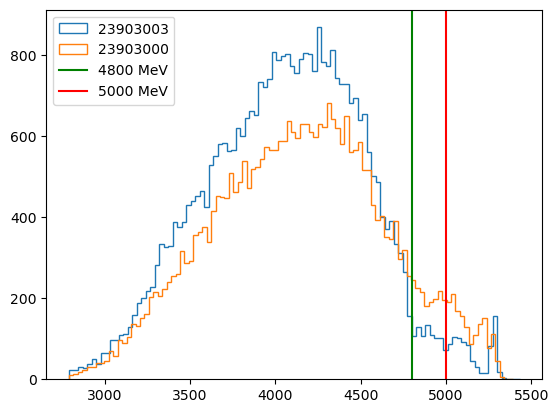

In [57]:
plt.hist(df23903003.B_M, bins=100, histtype='step', label='23903003')
plt.hist(df23903000.B_M, bins=100, histtype='step', label='23903000')
plt.axvline(x =4800, color = 'g', label = '4800 MeV')
plt.axvline(x =5000, color = 'r', label = '5000 MeV')
plt.legend();

In [58]:
g23903000_hb[0:10]

,p1_fromY_TOP,count,Percentage,cumulative %
0,511:513,1040,65.491184,65.491184
1,511,332,20.906801,86.397985
2,511:513:20523,41,2.581864,88.979849
3,511:525,22,1.385390,90.365239
4,511:513:525,22,1.385390,91.750630
5,511:513:20513,22,1.385390,93.136020
6,511:513:10523,17,1.070529,94.206549
7,511:513:20533,16,1.007557,95.214106
8,511:515,15,0.944584,96.158690
9,511:513:10513,10,0.629723,96.788413


In [59]:
g23903003_hb[0:10]

,p1_fromY_TOP,count,Percentage,cumulative %
0,511:513,501,60.216346,60.216346
1,511,187,22.475962,82.692308
2,511:513:20523,37,4.447115,87.139423
3,511:525,20,2.403846,89.543269
4,511:513:10523,14,1.682692,91.225962
5,511:513:20513,12,1.442308,92.668269
6,511:513:515,9,1.081731,93.750000
7,511:10521,8,0.961538,94.711538
8,511:513:525,8,0.961538,95.673077
9,511:513:20533,7,0.841346,96.514423
